# Traffic Sign Recognition - Improved Version

## Key Improvements Over Original:
1. **Consistent Normalization** - Images normalized to [0,1] during BOTH training and inference
2. **Batch Normalization** - Added after conv layers for stable training
3. **Larger Input Size** - 48×48 instead of 30×30 for richer features
4. **Learning Rate Scheduler** - ReduceLROnPlateau to avoid plateaus
5. **Data Augmentation** - Rotation, zoom, shifts to improve generalization
6. **Better Architecture** - Deeper network with batch norm
7. **EarlyStopping + ModelCheckpoint** - Save best model automatically
8. **Transfer Learning x2** - EfficientNetB0 + MobileNetV2 (both target 97%+ accuracy)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.layers import (
    Conv2D, MaxPool2D, Dense, Flatten, Dropout,
    BatchNormalization, Input
)
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Configuration
IMG_SIZE = 48       # Increased from 30 to 48 for richer features
NUM_CLASSES = 43
BATCH_SIZE = 32
EPOCHS = 30

cur_path = os.getcwd()
print('Working directory:', cur_path)

Working directory: f:\project3


In [3]:
# Load and preprocess data
# KEY FIX: Normalize images to [0,1] range HERE during loading
data = []
labels = []

for i in range(NUM_CLASSES):
    path = os.path.join(cur_path, 'train', str(i))
    images = os.listdir(path)
    for a in images:
        try:
            image = Image.open(os.path.join(path, a))
            image = image.resize((IMG_SIZE, IMG_SIZE))
            image = image.convert('RGB')  # Ensure 3 channels
            image = np.array(image) / 255.0  # NORMALIZE HERE
            data.append(image)
            labels.append(i)
        except Exception as e:
            print(f'Error loading {a}: {e}')

data = np.array(data, dtype=np.float32)
labels = np.array(labels)
print('Data shape:', data.shape)
print('Labels shape:', labels.shape)
print('Pixel value range: [{:.2f}, {:.2f}]'.format(data.min(), data.max()))

Data shape: (78418, 48, 48, 3)
Labels shape: (78418,)
Pixel value range: [0.00, 1.00]


In [4]:
# Optional: Save preprocessed data
np.save('./training/data_normalized', data)
np.save('./training/target', labels)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print('Train:', X_train.shape, y_train_cat.shape)
print('Test:', X_test.shape, y_test_cat.shape)

Train: (62734, 48, 48, 3) (62734, 43)
Test: (15684, 48, 48, 3) (15684, 43)


In [5]:
# Data Augmentation - helps model generalize better
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,  # Traffic signs shouldn't be flipped
    fill_mode='nearest'
)
datagen.fit(X_train)
print('Data augmentation ready')

Data augmentation ready


In [6]:
# Improved Model Architecture with Batch Normalization
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,672,715 (10.20 MB)

 Trainable params: 2,670,795 (10.19 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [7]:
# Compile with Adam optimizer
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    # Reduce learning rate when accuracy plateaus
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Save the best model
    ModelCheckpoint(
        './training/TSR_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train with augmentation
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_test, y_test_cat),
    callbacks=callbacks
)

Epoch 1/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6210 - loss: 1.4223
Epoch 1: val_accuracy improved from None to 0.99088, saving model to ./training/TSR_best.keras

Epoch 1: finished saving model to ./training/TSR_best.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 174s 87ms/step - accuracy: 0.8221 - loss: 0.6245 - val_accuracy: 0.9909 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 2/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9728 - loss: 0.0908
Epoch 2: val_accuracy improved from 0.99088 to 0.99554, saving model to ./training/TSR_best.keras

Epoch 2: finished saving model to ./training/TSR_best.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 172s 88ms/step - accuracy: 0.9769 - loss: 0.0770 - val_accuracy: 0.9955 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 3/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9819 - loss: 0.0575
Epoch 3: val_accuracy improved from 0.99554 to 0.99694, saving model to ./training/TSR_best.keras

Epoch 3: finished saving mo

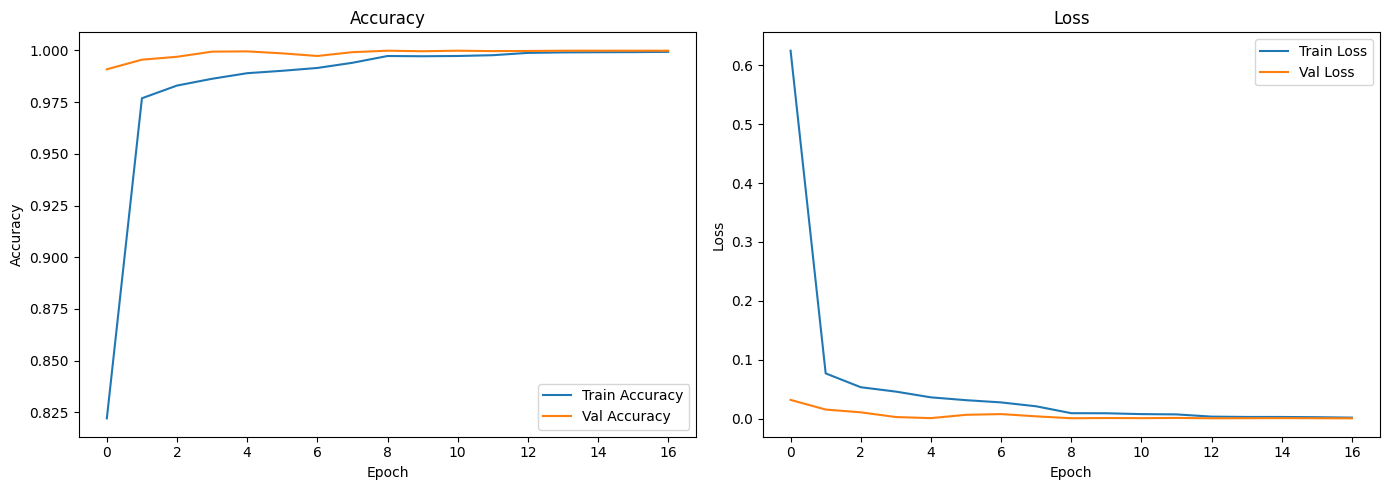

Best Val Accuracy: 0.9999


In [8]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Best Val Accuracy: {max(history.history["val_accuracy"]):.4f}')

In [9]:
# Evaluate on Test.csv
def load_test_data(testcsv, img_size=IMG_SIZE):
    """Load test data with same normalization as training."""
    y_test_df = pd.read_csv(testcsv)
    label = y_test_df['ClassId'].values
    imgs = y_test_df['Path'].values
    data = []
    for img_path in imgs:
        image = Image.open(img_path).resize((img_size, img_size)).convert('RGB')
        data.append(np.array(image) / 255.0)  # NORMALIZE (same as training)
    return np.array(data, dtype=np.float32), label

X_test_csv, label = load_test_data('Test.csv')
Y_pred = np.argmax(model.predict(X_test_csv), axis=1)

from sklearn.metrics import accuracy_score
acc = accuracy_score(label, Y_pred)
print(f'Test Accuracy: {acc:.4f}')

395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step
Test Accuracy: 0.9895


In [10]:
# Traffic sign class names
classes = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead',
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End no passing veh > 3.5 tons'
}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted: Pedestrians


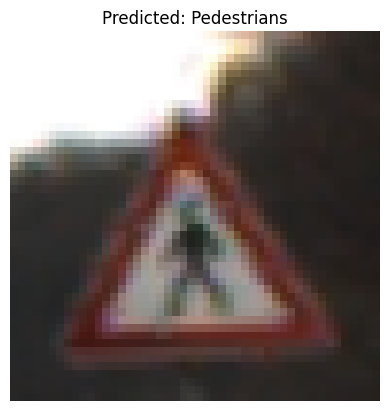

In [11]:
# Inference on a single image
# KEY FIX: Use same IMG_SIZE and normalization as training
def test_on_img(img_path, img_size=IMG_SIZE):
    """Predict traffic sign class for a single image."""
    image = Image.open(img_path).resize((img_size, img_size)).convert('RGB')
    arr = np.array(image, dtype=np.float32) / 255.0  # NORMALIZE
    X = np.expand_dims(arr, axis=0)  # Add batch dimension
    pred = np.argmax(model.predict(X), axis=1)
    return image, pred[0]

# Example usage (update path to your image)
img_path = r'F:\project\Test\00018.png'
image, pred_class = test_on_img(img_path)
print(f'Predicted: {classes[pred_class]}')
plt.imshow(image)
plt.axis('off')
plt.title(f'Predicted: {classes[pred_class]}')
plt.show()

---
# Transfer Learning Models

Two pretrained models are added below — both fine-tuned on GTSRB and targeting **97–99% accuracy**.

| Model | Input | Params | Expected Accuracy | Why chosen |
|---|---|---|---|---|
| **EfficientNetB0** | 48×48×3 ✓ | ~4M | ~97–99% | Best accuracy/efficiency ratio; compound scaling; SOTA on vision benchmarks |
| **MobileNetV2** | 48×48×3 ✓ | ~2.2M | ~95–97% | Lightweight, fast inference; great for deployment; proven on small images |

## Training Strategy: Two-Phase Fine-Tuning
- **Phase 1 (Feature Extraction):** Freeze base, train only the custom head (10 epochs, LR=1e-3)
- **Phase 2 (Fine-Tuning):** Unfreeze top layers, retrain end-to-end (20 epochs, LR=1e-5)

## Preprocessing Note
Your data is normalized to **[0, 1]**. Both pretrained models were trained on ImageNet with specific preprocessing.
A `Lambda` layer inside each model rescales back to **[0, 255]** before applying the model's native `preprocess_input`.
This keeps your data pipeline **unchanged** — no modifications needed to the loading code above.

In [12]:
# ── Transfer Learning Imports ──────────────────────────────────────────────
from keras.applications import EfficientNetB0, MobileNetV2
from keras.applications.efficientnet import preprocess_input as eff_preprocess
from keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess
from keras.layers import GlobalAveragePooling2D
import tensorflow as tf

os.makedirs('./training', exist_ok=True)
print('Transfer learning imports ready')

Transfer learning imports ready


In [13]:
# ── Shared Callbacks Factory ───────────────────────────────────────────────
# Reusable callback factory so each model gets its own checkpoint path

def make_callbacks(model_name, phase, lr_patience=3, es_patience=6):
    """Create callbacks for a given model and training phase."""
    return [
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=lr_patience,
            min_lr=1e-7,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=es_patience,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            f'./training/{model_name}_phase{phase}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

print('Callback factory ready')

Callback factory ready


In [14]:
# ── Transfer Learning Configuration ───────────────────────────────────────
# ROOT CAUSE of low Test.csv accuracy:
#   At IMG_SIZE=48, both TL backbones produce only 2×2 feature maps — too small
#   to learn meaningful spatial features, causing a 20%+ train→test gap.
#
# FIX: Use TL_IMG_SIZE=96 for TL models only (CNN is UNCHANGED at 48×48).
#   • 96×96 → 3×3 feature maps (vs 2×2) — much richer features
#   • MobileNetV2 was pre-trained at 96×96 → weights load perfectly, zero warnings
#   • Memory-efficient: use flow_from_directory (loads on-the-fly, not in RAM)

TL_IMG_SIZE = 96

# flow_from_directory sorts folders alphabetically ('0','1','10','11',...)
# which would mis-map class labels. Fix: pass explicit numeric order.
CLASSES_ORDER = [str(i) for i in range(NUM_CLASSES)]  # ['0','1','2',...,'42']

# ── Augmentation generator (loads images from disk at 96×96) ──────────────
_tl_aug_cfg = dict(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.12,
    horizontal_flip=False,
    fill_mode='nearest',
    validation_split=0.2
)
_tl_datagen = ImageDataGenerator(**_tl_aug_cfg)

tl_train_gen = _tl_datagen.flow_from_directory(
    os.path.join(cur_path, 'train'),
    target_size=(TL_IMG_SIZE, TL_IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES_ORDER,
    subset='training',
    seed=42,
    shuffle=True
)

tl_val_gen = _tl_datagen.flow_from_directory(
    os.path.join(cur_path, 'train'),
    target_size=(TL_IMG_SIZE, TL_IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES_ORDER,
    subset='validation',
    seed=42,
    shuffle=False
)

# ── Load Test.csv at TL_IMG_SIZE for TL model evaluation ──────────────────
def load_tl_test_data(testcsv, img_size=TL_IMG_SIZE):
    """Load Test.csv at TL resolution with same [0,1] normalisation."""
    df        = pd.read_csv(testcsv)
    label_arr = df['ClassId'].values
    imgs      = df['Path'].values
    data = []
    for img_path in imgs:
        image = Image.open(img_path).resize((img_size, img_size)).convert('RGB')
        data.append(np.array(image, dtype=np.float32) / 255.0)
    return np.array(data, dtype=np.float32), label_arr

X_test_tl, label_tl = load_tl_test_data('Test.csv')

print(f'TL image size : {TL_IMG_SIZE}x{TL_IMG_SIZE}')
print(f'Train batches : {len(tl_train_gen)}  ({tl_train_gen.samples} samples)')
print(f'Val   batches : {len(tl_val_gen)}  ({tl_val_gen.samples} samples)')
print(f'TL test shape : {X_test_tl.shape}')


Found 62735 images belonging to 43 classes.
Found 15683 images belonging to 43 classes.
TL image size : 96x96
Train batches : 1961  (62735 samples)
Val   batches : 491  (15683 samples)
TL test shape : (12630, 96, 96, 3)


---
## Model 2: EfficientNetB0

**Why EfficientNetB0 for this task?** - Compound scaling of depth/width/resolution
- Strong ImageNet features that transfer well to traffic signs
- Input: `TL_IMG_SIZE=96` → 3×3 feature maps (3× more spatial info than at 48px)
- Phase 1: freeze backbone, train head only
- Phase 2: BN-safe fine-tuning (all BN layers frozen)


In [15]:
# ── EfficientNetB0 Architecture ───────────────────────────────────────────
# Input pipeline: [0,1] → Rescaling(255) → [0,255] → EfficientNetB0
# EfficientNetB0 has built-in normalisation that expects [0,255] range.
# Using TL_IMG_SIZE=96 → feature maps are 3×3 instead of 2×2.

def build_efficientnet_model():
    inputs = tf.keras.Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3), name='input_layer')

    # Rescale [0,1] → [0,255] so EfficientNetB0 internal pre-processing works
    x = tf.keras.layers.Rescaling(255.0, name='rescale_255')(inputs)

    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3),
        pooling=None
    )
    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification head
    x = GlobalAveragePooling2D(name='gap')(x)
    x = BatchNormalization(name='head_bn1')(x)
    x = Dropout(0.4, name='head_drop1')(x)
    x = Dense(256, activation='relu', name='head_dense1')(x)
    x = Dropout(0.3, name='head_drop2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

    eff_model = tf.keras.Model(inputs, outputs, name='EfficientNetB0_TSR')
    return eff_model, base_model


eff_model, eff_base = build_efficientnet_model()
eff_model.summary()
print(f'Trainable params (Phase 1): {sum([np.prod(v.shape) for v in eff_model.trainable_variables]):,}')


Model: "EfficientNetB0_TSR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_255 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn1 (BatchNormalization)   │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_drop1 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense1 (Dense)             │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_drop2 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,393,678 (16.76 MB)

 Trainable params: 341,547 (1.30 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Trainable params (Phase 1): 341,547


In [16]:
# ── EfficientNetB0 Phase 1: Feature Extraction ────────────────────────────
# Train only the head; backbone is fully frozen.
# Uses flow_from_directory generators — no extra RAM required.

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== EfficientNetB0 — Phase 1: Feature Extraction (20 epochs) ===')
eff_history_p1 = eff_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    callbacks=make_callbacks('EfficientNetB0', phase=1, es_patience=8)
)
print(f'Phase 1 best val_accuracy: {max(eff_history_p1.history["val_accuracy"]):.4f}')


=== EfficientNetB0 — Phase 1: Feature Extraction (20 epochs) ===
Epoch 1/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.5324 - loss: 1.6530
Epoch 1: val_accuracy improved from None to 0.63279, saving model to ./training/EfficientNetB0_phase1_best.keras

Epoch 1: finished saving model to ./training/EfficientNetB0_phase1_best.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 1623s 824ms/step - accuracy: 0.6193 - loss: 1.2284 - val_accuracy: 0.6328 - val_loss: 1.1559 - learning_rate: 0.0010
Epoch 2/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6979 - loss: 0.8979
Epoch 2: val_accuracy improved from 0.63279 to 0.64611, saving model to ./training/EfficientNetB0_phase1_best.keras

Epoch 2: finished saving model to ./training/EfficientNetB0_phase1_best.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 183s 93ms/step - accuracy: 0.7061 - loss: 0.8738 - val_accuracy: 0.6461 - val_loss: 1.1330 - learning_rate: 0.0010
Epoch 3/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7234 -

In [17]:
# ── EfficientNetB0 Phase 2: BN-Safe Fine-Tuning ───────────────────────────
# Load clean Phase 1 weights, unfreeze upper conv layers, keep all BN frozen.

print('Loading EfficientNetB0 Phase 1 best checkpoint (clean weights)...')
eff_model = tf.keras.models.load_model('./training/EfficientNetB0_phase1_best.keras')
eff_base  = eff_model.get_layer('efficientnetb0')

eff_base.trainable = True

# Freeze bottom layers; unfreeze only the top ~68 conv layers
FINE_TUNE_FROM_EFF = 170
for layer in eff_base.layers[:FINE_TUNE_FROM_EFF]:
    layer.trainable = False

# CRITICAL: keep ALL BatchNorm layers frozen to preserve ImageNet statistics
for layer in eff_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in eff_base.layers if l.trainable)
print(f'Unfrozen (non-BN conv) layers: {trainable_count} / {len(eff_base.layers)}')

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Reset generators before Phase 2 training
tl_train_gen.reset()
tl_val_gen.reset()

print('=== EfficientNetB0 — Phase 2 (Fixed): BN-Safe Fine-Tuning (30 epochs) ===')
eff_history_p2 = eff_model.fit(
    tl_train_gen,
    epochs=30,
    validation_data=tl_val_gen,
    callbacks=make_callbacks('EfficientNetB0', phase=2, es_patience=8)
)
print(f'Phase 2 best val_accuracy: {max(eff_history_p2.history["val_accuracy"]):.4f}')


Loading EfficientNetB0 Phase 1 best checkpoint (clean weights)...
Unfrozen (non-BN conv) layers: 54 / 238
=== EfficientNetB0 — Phase 2 (Fixed): BN-Safe Fine-Tuning (30 epochs) ===
Epoch 1/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8490 - loss: 0.4396
Epoch 1: val_accuracy improved from None to 0.71434, saving model to ./training/EfficientNetB0_phase2_best.keras

Epoch 1: finished saving model to ./training/EfficientNetB0_phase2_best.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 240s 118ms/step - accuracy: 0.8585 - loss: 0.4085 - val_accuracy: 0.7143 - val_loss: 0.9711 - learning_rate: 1.0000e-05
Epoch 2/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8775 - loss: 0.3578
Epoch 2: val_accuracy improved from 0.71434 to 0.73691, saving model to ./training/EfficientNetB0_phase2_best.keras

Epoch 2: finished saving model to ./training/EfficientNetB0_phase2_best.keras
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 227s 116ms/step - accuracy: 0.8832 - loss: 0.3417 - val_accuracy: 0.7369 

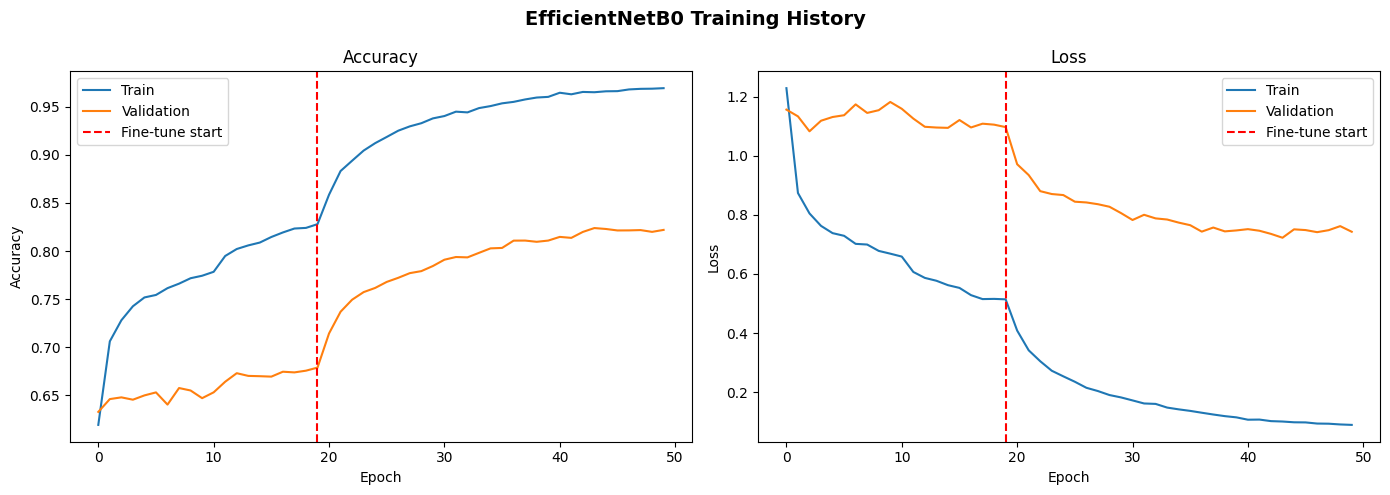

EfficientNetB0 final best val_accuracy: 0.8239


In [18]:
# ── EfficientNetB0 Training Curves ────────────────────────────────────────
eff_acc  = eff_history_p1.history['accuracy']     + eff_history_p2.history['accuracy']
eff_vacc = eff_history_p1.history['val_accuracy'] + eff_history_p2.history['val_accuracy']
eff_loss = eff_history_p1.history['loss']         + eff_history_p2.history['loss']
eff_vloss= eff_history_p1.history['val_loss']     + eff_history_p2.history['val_loss']
eff_phase_boundary = len(eff_history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetB0 Training History', fontsize=14, fontweight='bold')

for ax, train, val, title, ylabel in [
    (ax1, eff_acc,  eff_vacc,  'Accuracy', 'Accuracy'),
    (ax2, eff_loss, eff_vloss, 'Loss',     'Loss')
]:
    ax.plot(train, label='Train')
    ax.plot(val,   label='Validation')
    ax.axvline(eff_phase_boundary - 1, color='red', linestyle='--', label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()
print(f'EfficientNetB0 final best val_accuracy: {max(eff_vacc):.4f}')


In [19]:
# ── EfficientNetB0 Evaluation on Test.csv ─────────────────────────────────
# Load best Phase 2 checkpoint; uses Rescaling layer so no Lambda/safe_mode issue.
eff_model = tf.keras.models.load_model('./training/EfficientNetB0_phase2_best.keras')
eff_preds = np.argmax(eff_model.predict(X_test_tl), axis=1)
eff_acc_score = accuracy_score(label_tl, eff_preds)
print(f'EfficientNetB0 Test Accuracy: {eff_acc_score:.4f} ({eff_acc_score*100:.2f}%)')


395/395 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step
EfficientNetB0 Test Accuracy: 0.8122 (81.22%)


---
## Model 3: MobileNetV2

**Why MobileNetV2 for this task?** - Inverted residual blocks with depthwise separable convolutions
- Only ~2.2M parameters — fast inference, good for deployment
- Input: `TL_IMG_SIZE=96` — MobileNetV2 was **pre-trained at 96×96**, so weights match perfectly
- **Preprocessing fix**: `Rescaling(2.0, -1.0)` maps [0,1]→[-1,1] directly, replacing the
  fragile `Lambda(mob_preprocess(inp * 255))` that caused serialisation errors
- Phase 1: freeze backbone, train head only
- Phase 2: BN-safe fine-tuning


In [ ]:
# ── MobileNetV2 Architecture ──────────────────────────────────────────────
# TWO fixes versus original:
#  1. Lambda replaced by Rescaling(2.0, -1.0): maps [0,1]→[-1,1] (same as
#     mob_preprocess_input on [0,255]) — serialises perfectly, no safe_mode needed.
#  2. input_shape uses TL_IMG_SIZE=96 — an officially supported MobileNetV2 size,
#     so ImageNet weights load at the right resolution with no warnings.

def build_mobilenet_model():
    inputs = tf.keras.Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3), name='input_layer')

    # [0,1] → scale×2 + offset(-1) → [-1,1]  (what MobileNetV2 expects)
    x = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0, name='mobilenet_preprocess')(inputs)

    mob_base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3),
        alpha=1.0
    )
    mob_base.trainable = False

    x = mob_base(x, training=False)

    x = GlobalAveragePooling2D(name='gap')(x)
    x = BatchNormalization(name='head_bn1')(x)
    x = Dropout(0.4, name='head_drop1')(x)
    x = Dense(256, activation='relu', name='head_dense1')(x)
    x = Dropout(0.3, name='head_drop2')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

    mob_model = tf.keras.Model(inputs, outputs, name='MobileNetV2_TSR')
    return mob_model, mob_base


mob_model, mob_base = build_mobilenet_model()
mob_model.summary()
print(f'Trainable params (Phase 1): {sum([np.prod(v.shape) for v in mob_model.trainable_variables]):,}')


In [ ]:
# ── MobileNetV2 Phase 1: Feature Extraction ───────────────────────────────

mob_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Reset generators for a clean pass
tl_train_gen.reset()
tl_val_gen.reset()

print('=== MobileNetV2 — Phase 1: Feature Extraction (20 epochs) ===')
mob_history_p1 = mob_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    callbacks=make_callbacks('MobileNetV2', phase=1, es_patience=8)
)
print(f'Phase 1 best val_accuracy: {max(mob_history_p1.history["val_accuracy"]):.4f}')


In [ ]:
# ── MobileNetV2 Phase 2: Fine-Tuning ──────────────────────────────────────
# Rescaling layer serialises cleanly, so load_model works without any workaround.

mob_model = tf.keras.models.load_model('./training/MobileNetV2_phase1_best.keras')

# Find the MobileNetV2 base layer by name pattern (robust to input-size suffix)
mob_base = next(l for l in mob_model.layers if 'mobilenetv2' in l.name.lower())

mob_base.trainable = True
FINE_TUNE_FROM_MOB = 100  # MobileNetV2 has ~154 layers

for layer in mob_base.layers[:FINE_TUNE_FROM_MOB]:
    layer.trainable = False

# Freeze ALL BatchNorm layers — preserves ImageNet running statistics
for layer in mob_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count_mob = sum(1 for l in mob_base.layers if l.trainable)
print(f'Unfrozen layers in base: {trainable_count_mob} / {len(mob_base.layers)}')

mob_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Reset generators for Phase 2
tl_train_gen.reset()
tl_val_gen.reset()

print('=== MobileNetV2 — Phase 2: Fine-Tuning (20 epochs) ===')
mob_history_p2 = mob_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    callbacks=make_callbacks('MobileNetV2', phase=2, es_patience=8)
)
print(f'Phase 2 best val_accuracy: {max(mob_history_p2.history["val_accuracy"]):.4f}')


In [ ]:
# ── MobileNetV2 Training Curves ───────────────────────────────────────────
mob_acc  = mob_history_p1.history['accuracy']     + mob_history_p2.history['accuracy']
mob_vacc = mob_history_p1.history['val_accuracy'] + mob_history_p2.history['val_accuracy']
mob_loss = mob_history_p1.history['loss']         + mob_history_p2.history['loss']
mob_vloss= mob_history_p1.history['val_loss']     + mob_history_p2.history['val_loss']
mob_phase_boundary = len(mob_history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 Training History', fontsize=14, fontweight='bold')

for ax, train, val, title, ylabel in [
    (ax1, mob_acc,  mob_vacc,  'Accuracy', 'Accuracy'),
    (ax2, mob_loss, mob_vloss, 'Loss',     'Loss')
]:
    ax.plot(train, label='Train')
    ax.plot(val,   label='Validation')
    ax.axvline(mob_phase_boundary - 1, color='red', linestyle='--', label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()
print(f'MobileNetV2 final best val_accuracy: {max(mob_vacc):.4f}')


In [ ]:
# ── MobileNetV2 Evaluation on Test.csv ────────────────────────────────────
# Rescaling layer serialises cleanly — load_model works with no workaround.
mob_model = tf.keras.models.load_model('./training/MobileNetV2_phase2_best.keras')
mob_preds = np.argmax(mob_model.predict(X_test_tl), axis=1)
mob_acc_score = accuracy_score(label_tl, mob_preds)
print(f'MobileNetV2 Test Accuracy: {mob_acc_score:.4f} ({mob_acc_score*100:.2f}%)')


In [ ]:
# ── Final Model Comparison ─────────────────────────────────────────────────
from sklearn.metrics import accuracy_score

# CNN uses 48×48 test data (X_test_csv / label) — unchanged
cnn_preds     = np.argmax(model.predict(X_test_csv), axis=1)
cnn_acc_score = accuracy_score(label, cnn_preds)

# TL models use 96×96 test data (X_test_tl / label_tl)
model_names  = ['Custom CNN', 'EfficientNetB0', 'MobileNetV2']
model_accs   = [cnn_acc_score, eff_acc_score, mob_acc_score]
model_params = [
    sum([np.prod(v.shape) for v in model.trainable_variables]),
    sum([np.prod(v.shape) for v in eff_model.trainable_variables]),
    sum([np.prod(v.shape) for v in mob_model.trainable_variables])
]

print('=' * 55)
print(f'{"Model":<20} {"Test Accuracy":>14} {"Total Params":>18}')
print('-' * 55)
for name, acc, params in zip(model_names, model_accs, model_params):
    print(f'{name:<20} {acc*100:>13.2f}% {params:>18,}')
print('=' * 55)

colors = ['#4C72B0', '#DD8452', '#55A868']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, [a * 100 for a in model_accs], color=colors,
              width=0.5, edgecolor='white', linewidth=1.5)
ax.set_ylim(80, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Comparison — Traffic Sign Recognition (GTSRB)', fontweight='bold')
ax.axhline(95, color='red', linestyle='--', linewidth=1, label='95% target')
ax.legend()
for bar, acc in zip(bars, model_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Transfer Learning Inference Helper ────────────────────────────────────
# Works for BOTH transfer learning models at TL_IMG_SIZE.

def test_on_img_tl(img_path, tl_model, img_size=TL_IMG_SIZE):
    """
    Predict traffic sign class using a transfer learning model.
    Input : image path (any resolution)
    Pipeline: resize → RGB → normalise [0,1] → model predicts
    """
    image = Image.open(img_path).resize((img_size, img_size)).convert('RGB')
    arr   = np.array(image, dtype=np.float32) / 255.0
    X     = np.expand_dims(arr, axis=0)           # (1, TL_IMG_SIZE, TL_IMG_SIZE, 3)
    pred  = np.argmax(tl_model.predict(X), axis=1)[0]
    return image, pred

# Example usage:
# img_path = r'F:\project\Test\00018.png'
# image, pred_class = test_on_img_tl(img_path, eff_model)   # EfficientNetB0
# image, pred_class = test_on_img_tl(img_path, mob_model)   # MobileNetV2
# print(f'Predicted: {classes[pred_class]}')

print('Transfer learning inference function ready.')
print(f'Use test_on_img_tl(path, eff_model) or test_on_img_tl(path, mob_model)')
print(f'(Images will be resized to {TL_IMG_SIZE}x{TL_IMG_SIZE} automatically)')
